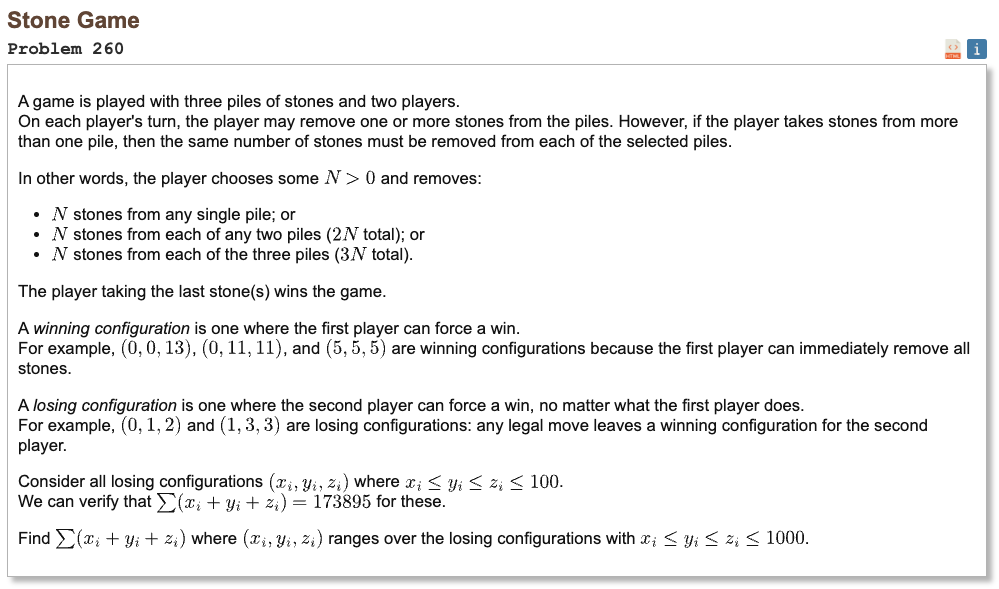

## Initial approach

* this is a normal play impartial game so positions are winning or losing
* a position is losing if every legal move goes to a winning position
* moves are removing k from one pile, from two piles equally, or from all three equally
* restrict to ordered triples a ≤ b ≤ c and only consider sums up to 1000
* build a 3D table dp[a][b][c] marking losing or winning
* iterate increasing by total a+b+c so smaller positions are already known
* if no move leads to losing then current is losing
* sum a+b+c over all losing configurations and print

In [1]:
MAX = 1000

def solve():
    losing = [[[False]*(MAX+1) for _ in range(MAX+1)] for __ in range(MAX+1)]

    total_sum = 0

    for s in range(MAX+1):
        for a in range(s+1):
            for b in range(a, s+1):
                c = s - a - b
                if c < b or c > MAX:
                    continue

                win = False

                for k in range(1, a+1):
                    if not losing[a-k][b][c]:
                        win = True
                        break
                if not win:
                    for k in range(1, b+1):
                        if not losing[a][b-k][c]:
                            win = True
                            break
                if not win:
                    for k in range(1, c+1):
                        if not losing[a][b][c-k]:
                            win = True
                            break
                if not win:
                    for k in range(1, a+1):
                        if not losing[a-k][b-k][c]:
                            win = True
                            break
                if not win:
                    for k in range(1, a+1):
                        if not losing[a-k][b][c-k]:
                            win = True
                            break
                if not win:
                    for k in range(1, b+1):
                        if not losing[a][b-k][c-k]:
                            win = True
                            break
                if not win:
                    for k in range(1, a+1):
                        if not losing[a-k][b-k][c-k]:
                            win = True
                            break

                losing[a][b][c] = not win

                if not win:
                    total_sum += a + b + c

    print("Result:", total_sum)

In [2]:
%%time
solve()

Result: 500500
CPU times: user 28.5 s, sys: 4.55 s, total: 33.1 s
Wall time: 35.4 s
